- Evan Griffin practice notes one


# – Exploratory Data Analysis

In [110]:
!pip install numpy pandas matplotlib seaborn scikit-learn


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [111]:
# imports 

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

In [112]:
# Created seed using my student number
SEED = 419296
np.random.seed(SEED)

In [113]:
#load data from csv file
df = pd.read_csv("diabetes.csv")

df.shape
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [114]:
# code to check for missing values in the dataset
df.isna().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

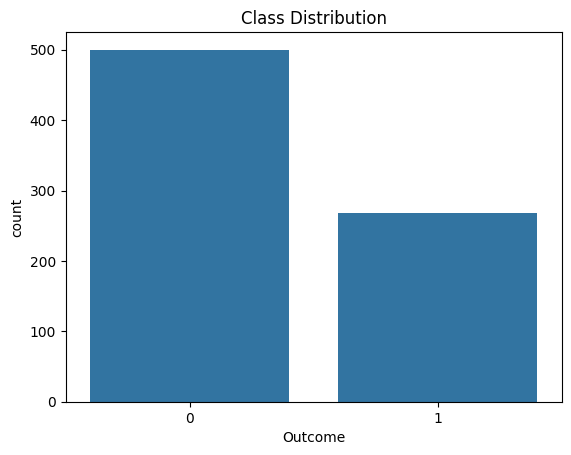

Outcome
0    0.651042
1    0.348958
Name: proportion, dtype: float64

In [115]:
#shows how many samples belong to each class
sns.countplot(x=df["Outcome"])
plt.title("Class Distribution")
plt.show()

df["Outcome"].value_counts(normalize=True)

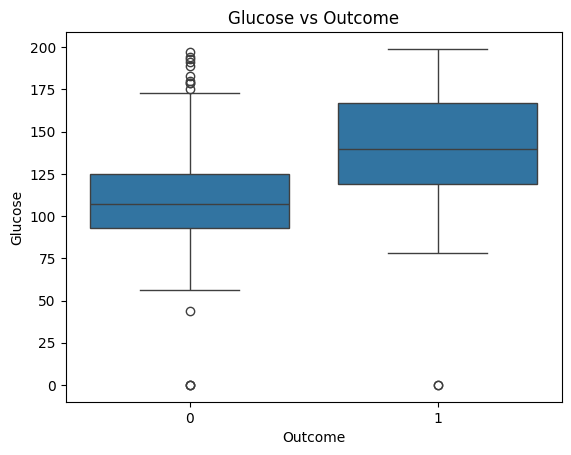

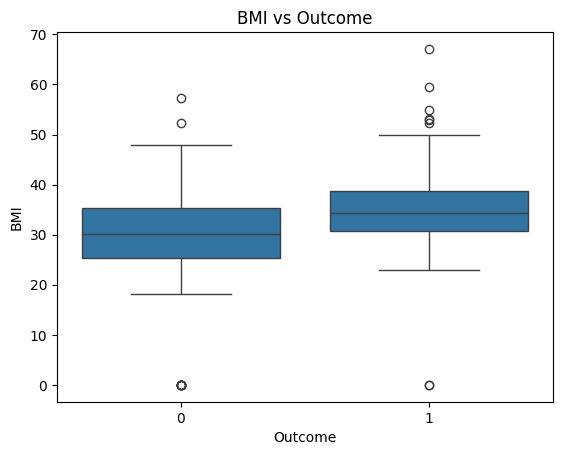

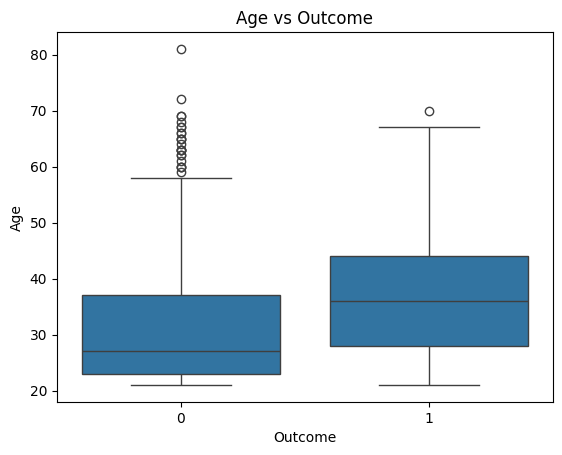

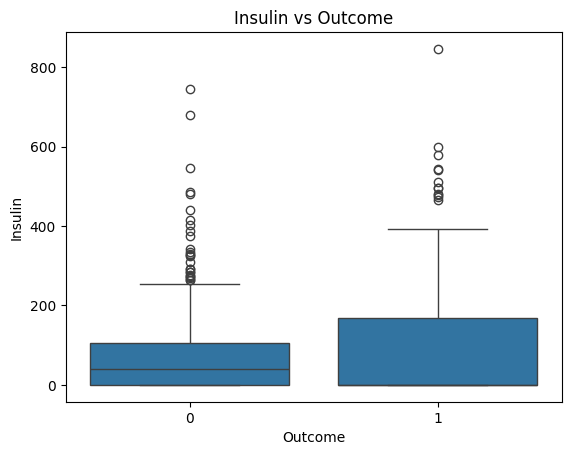

In [116]:
#code to check how many samples belong to each class
features = ["Glucose","BMI","Age","Insulin"]

for f in features:
    sns.boxplot(x=df["Outcome"], y=df[f])
    plt.title(f"{f} vs Outcome")
    plt.show()

The class distribution shows that the dataset is moderately imbalanced, with more non-diabetic cases than diabetic cases. This imbalance should be considered when evaluating model performance because accuracy alone may not fully reflect performance on the minority class. Metrics such as F1 score will therefore also be used when comparing models.

# – Data Preparation

In [117]:
# convert fake zeros to NaN

cols = ["Glucose","BloodPressure","SkinThickness","Insulin","BMI"]

for c in cols:
    df[c] = df[c].replace(0, np.nan)

In [118]:
#quick test
df[cols].isna().sum()

Glucose            5
BloodPressure     35
SkinThickness    227
Insulin          374
BMI               11
dtype: int64

In [119]:
#define target and features
y = df["Outcome"]
X = df.drop(columns=["Outcome"])

In [120]:
#d60/20/20 split stratified by the target variable to maintain class distribution in each set

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.40, stratify=y, random_state=SEED
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=SEED
)

X_train.shape, X_val.shape, X_test.shape

((460, 8), (154, 8), (154, 8))

In [121]:
#optional extra test
y.value_counts(normalize=True), y_train.value_counts(normalize=True), y_val.value_counts(normalize=True), y_test.value_counts(normalize=True)

(Outcome
 0    0.651042
 1    0.348958
 Name: proportion, dtype: float64,
 Outcome
 0    0.65
 1    0.35
 Name: proportion, dtype: float64,
 Outcome
 0    0.655844
 1    0.344156
 Name: proportion, dtype: float64,
 Outcome
 0    0.649351
 1    0.350649
 Name: proportion, dtype: float64)

Some features in the diabetes dataset contain zero values that are physiologically unrealistic (e.g., Glucose, BMI, Insulin), which likely represent missing measurements. These zeros were replaced with NaN so that they can be handled correctly during preprocessing. The dataset was then split into training (60%), validation (20%), and test (20%) sets using stratified sampling to preserve the original class distribution across splits. A fixed random seed based on the student ID was used to ensure reproducibility.

# – Model Training

In [122]:
# KNN model 

pipe_knn = make_pipeline(
    SimpleImputer(strategy="median"),
    StandardScaler(),
    KNeighborsClassifier()
)

grid_knn = {
    "kneighborsclassifier__n_neighbors":[3,5,7,9],
    "kneighborsclassifier__weights":["uniform","distance"]
}

gs_knn = GridSearchCV(pipe_knn, grid_knn, cv=5, scoring="f1")

gs_knn.fit(X_train,y_train)

gs_knn.best_params_, gs_knn.best_score_

({'kneighborsclassifier__n_neighbors': 7,
  'kneighborsclassifier__weights': 'uniform'},
 np.float64(0.5913725726207671))

K-Nearest Neighbours was selected as a baseline model because it is simple and effective for datasets where class separation may exist in feature space. Because KNN relies on distance calculations, feature scaling is required to ensure all features contribute equally. Hyperparameters such as the number of neighbours and weighting strategy were tuned using GridSearchCV to find the optimal configuration.

In [123]:
# Logistic Regression model

pipe_lr = make_pipeline(
    SimpleImputer(strategy="median"),
    StandardScaler(),
    LogisticRegression(max_iter=1000)
)

grid_lr = {
    "logisticregression__C":[0.01,0.1,1,10],
    "logisticregression__solver":["liblinear","lbfgs"]
}

gs_lr = GridSearchCV(pipe_lr, grid_lr, cv=5, scoring="f1")

gs_lr.fit(X_train,y_train)

gs_lr.best_params_, gs_lr.best_score_

({'logisticregression__C': 0.01, 'logisticregression__solver': 'liblinear'},
 np.float64(0.649612585741618))

Logistic Regression was selected because it is a strong baseline model for binary classification problems. It assumes a linear relationship between the features and the log-odds of the target variable. Feature scaling is applied because logistic regression is sensitive to the scale of input features. Hyperparameters including the regularization strength (C) and solver were tuned using GridSearchCV to identify the best performing configuration.

In [124]:
# Random Forest model

pipe_rf = make_pipeline(
    SimpleImputer(strategy="median"),
    RandomForestClassifier(random_state=SEED)
)

grid_rf = {
    "randomforestclassifier__n_estimators":[100,200],
    "randomforestclassifier__max_depth":[None,5,10]
}

gs_rf = GridSearchCV(pipe_rf, grid_rf, cv=5, scoring="f1")

gs_rf.fit(X_train,y_train)

gs_rf.best_params_, gs_rf.best_score_

({'randomforestclassifier__max_depth': 5,
  'randomforestclassifier__n_estimators': 100},
 np.float64(0.6121771355903443))

markdown explanation

# – Validation Comparison

In [125]:
# created evalutaion function to evaluate models on validation and test sets using accuracy and f1 score

def evaluate_model(model, X, y):
    
    preds = model.predict(X)
    
    acc = accuracy_score(y, preds)
    f1 = f1_score(y, preds)
    
    return acc, f1

In [126]:
# evaluate all models on the validation set and store results in a dataframe for comparison

results = []

models = {
    "KNN": gs_knn.best_estimator_,
    "Logistic Regression": gs_lr.best_estimator_,
    "Random Forest": gs_rf.best_estimator_
}

for name, model in models.items():
    
    acc, f1 = evaluate_model(model, X_val, y_val)
    
    results.append({
        "Model": name,
        "Accuracy": acc,
        "F1 Score": f1
    })

results_df = pd.DataFrame(results)

results_df.sort_values("F1 Score", ascending=False)

,Model,Accuracy,F1 Score
0,KNN,0.792208,0.680000
2,Random Forest,0.779221,0.630435
1,Logistic Regression,0.746753,0.613861


The three tuned models were evaluated on the validation dataset using both accuracy and F1 score. Logistic Regression achieved the highest F1 score among the models, indicating the best balance between precision and recall. Although Random Forest and KNN also performed reasonably well, their F1 scores were slightly lower. Because the dataset contains some class imbalance, the F1 score provides a more informative measure of performance than accuracy alone. Based on these results, Logistic Regression was selected as the best model.

markdown explanation

# – Final Test Evaluation

In [127]:
# combine train and validation sets for final training of the best model before testing on the test set
X_trainval = pd.concat([X_train, X_val])
y_trainval = pd.concat([y_train, y_val])

In [128]:
# retrain best model (KNN in this case) on the combined train and validation set
final_model = gs_knn.best_estimator_

final_model.fit(X_trainval, y_trainval)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('simpleimputer', ...), ('standardscaler', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto account for missingness despite

In [129]:
#test predictions
test_preds = final_model.predict(X_test)

In [ ]:
#classification report 
print(classification_report(y_test, test_preds))

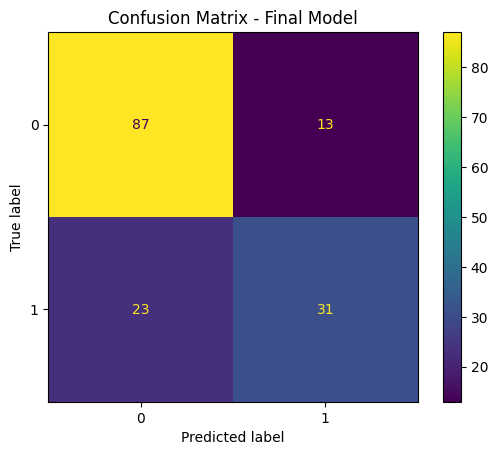

In [130]:
#confusion matrix of the final model on the test set

ConfusionMatrixDisplay.from_predictions(y_test, test_preds)

plt.title("Confusion Matrix - Final Model")
plt.show()

markdown explanation